# FP-Cox Optimizer — Self-adaptive Differential Evolution (SaDE)

This notebook is a **drop-in replacement** for the original `test_one.ipynb` DE-based approach.
The external API (`FPCoxOptimizer`, `optimize()`, etc.) is **identical** — only the internal
optimiser changes from `scipy.optimize.differential_evolution` → **SaDE**.

| | Original (scipy DE) | **SaDE** |
|---|---|---|
| Strategy | Fixed single strategy | **4 strategies, self-adapting** |
| F, CR | Fixed range / value | **Self-adapted per strategy** |
| Bounds | `(0, 15.999)` float trick | **`(0, 15)` — clean integer bounds** |
| Index extraction | `np.floor(result.x)` | **`result.x` — already integers** |

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter
from collections import deque
from dataclasses import dataclass, field
from typing import List
import warnings

warnings.filterwarnings("ignore")

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
#  SaDE Engine  (Self-adaptive Differential Evolution — integer search space)
# ─────────────────────────────────────────────────────────────────────────────

@dataclass
class _SaDEResult:
    x:       np.ndarray
    fun:     float
    nfev:    int
    ngen:    int
    history: List[float] = field(default_factory=list)


def _choose(n, k, excl, rng):
    cands = np.delete(np.arange(n), excl)
    return rng.choice(cands, size=k, replace=False)

def _s1(pop, F, t, b, rng):                              # DE/rand/1
    r1,r2,r3 = _choose(len(pop),3,t,rng)
    return pop[r1]+F*(pop[r2]-pop[r3])
def _s2(pop, F, t, b, rng):                              # DE/rand-to-best/2
    r1,r2,r3,r4 = _choose(len(pop),4,t,rng)
    return pop[t]+F*(pop[b]-pop[t])+F*(pop[r1]-pop[r2])+F*(pop[r3]-pop[r4])
def _s3(pop, F, t, b, rng):                              # DE/current-to-rand/1
    r1,r2,r3 = _choose(len(pop),3,t,rng)
    return pop[t]+F*(pop[r1]-pop[t])+F*(pop[r2]-pop[r3])
def _s4(pop, F, t, b, rng):                              # DE/rand/2
    r1,r2,r3,r4,r5 = _choose(len(pop),5,t,rng)
    return pop[r1]+F*(pop[r2]-pop[r3])+F*(pop[r4]-pop[r5])
_STRATS = [_s1,_s2,_s3,_s4]; _NS = len(_STRATS)


def _repair(v, lb, ub):
    v = np.round(v).astype(int)
    lo=v<lb; v[lo]=lb[lo]+(lb[lo]-v[lo])
    hi=v>ub; v[hi]=ub[hi]-(v[hi]-ub[hi])
    return np.clip(v,lb,ub)

def _cross(x, v, CR, rng):
    d=len(x); m=rng.random(d)<CR; m[rng.integers(d)]=True
    return np.where(m,v,x)


class _SaDE:
    def __init__(self, func, bounds, pop_size=50, max_evals=50_000,
                 lp=50, seed=None, callback=None):
        self.func=func; self.bounds=bounds; self.dim=len(bounds)
        self.lb=np.array([b[0] for b in bounds],dtype=int)
        self.ub=np.array([b[1] for b in bounds],dtype=int)
        self.N=pop_size; self.maxev=max_evals; self.lp=lp
        self.cb=callback
        self.rng=np.random.default_rng(seed)
        self.p=np.ones(_NS)/_NS
        self.crm=np.full(_NS,0.5)
        self.ns=[deque() for _ in range(_NS)]
        self.nf=[deque() for _ in range(_NS)]
        self.crok=[deque() for _ in range(_NS)]

    def run(self):
        pop=np.column_stack([self.rng.integers(self.lb[d],self.ub[d]+1,self.N)
                             for d in range(self.dim)])
        fit=np.array([self.func(pop[i]) for i in range(self.N)])
        nfev=self.N; bi=int(np.argmin(fit)); hist=[float(fit[bi])]
        gen=0
        while nfev<self.maxev:
            gen+=1
            for i in range(self.N):
                if nfev>=self.maxev: break
                k=self.rng.choice(_NS,p=self.p)
                F=float(np.clip(self.rng.standard_cauchy()*0.3+0.5,1e-6,2.0))
                CR=float(np.clip(self.rng.normal(self.crm[k],0.1),0.0,1.0))
                v=_STRATS[k](pop,F,i,bi,self.rng).astype(float)
                u=_repair(_cross(pop[i].astype(float),v,CR,self.rng),self.lb,self.ub)
                fu=self.func(u); nfev+=1
                if fu<=fit[i]:
                    pop[i],fit[i]=u,fu
                    self.ns[k].append(1); self.crok[k].append(CR)
                    if fu<fit[bi]: bi=i
                else:
                    self.nf[k].append(1)
            if gen%self.lp==0: self._upd_p(); self._upd_crm()
            hist.append(float(fit[bi]))
            if self.cb: self.cb(pop[bi],fit[bi],gen)
        return _SaDEResult(x=pop[bi].copy(),fun=float(fit[bi]),nfev=nfev,ngen=gen,history=hist)

    def _upd_p(self):
        ns=np.array([sum(q) for q in self.ns],dtype=float)
        nf=np.array([sum(q) for q in self.nf],dtype=float)
        with np.errstate(divide='ignore',invalid='ignore'):
            r=np.where(ns+nf>0,ns/(ns+nf),0.0)
        tot=r.sum()
        if tot>0: self.p=0.01+0.99*r/tot; self.p/=self.p.sum()
        for k in range(_NS):
            while len(self.ns[k])>self.lp: self.ns[k].popleft()
            while len(self.nf[k])>self.lp: self.nf[k].popleft()

    def _upd_crm(self):
        for k in range(_NS):
            if self.crok[k]: self.crm[k]=float(np.median(list(self.crok[k])))
            while len(self.crok[k])>self.lp: self.crok[k].popleft()

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
#  FPCoxOptimizer  — same public API as the original DE-based class
#                    internally powered by SaDE
# ─────────────────────────────────────────────────────────────────────────────

class FPCoxOptimizer:
    def __init__(self, df, covariates, duration_col, event_col, penalizer=0.01):
        """
        Initializes the FP-Cox optimizer.

        Parameters
        ----------
        df           : pandas DataFrame
        covariates   : list of continuous covariate column names
        duration_col : survival-time column name
        event_col    : event-indicator column name
        penalizer    : Cox model penalizer (default 0.01)
        """
        self.covariates   = covariates
        self.duration_col = duration_col
        self.event_col    = event_col
        self.penalizer    = penalizer
        self.power_set    = [None,-3,-2.5,-2,-1.5,-1,-0.5,-0.25,0,
                             0.25,0.5,1,1.5,2,2.5,3]
        self.n_powers     = len(self.power_set)  # 16 → valid indices 0..15

        # Preprocess: ensure all covariates are strictly positive floats
        self.df = self._preprocess_positive(df, covariates)

        # State
        self.evaluation_cache = {}
        self.best_val         = np.inf
        self.history          = []
        self.best_powers      = []
        self.final_fp_model   = None
        self.traditional_model = None

    # ── Preprocessing ─────────────────────────────────────────────────────────
    def _preprocess_positive(self, df, features):
        """Ensures all continuous features are strictly positive floats."""
        df_copy = df.copy()
        for col in features:
            x = df_copy[col].astype(float)
            if (x <= 0).any():
                df_copy[col] = x - x.min() + 1e-5
            else:
                df_copy[col] = x
        return df_copy

    # ── Feature generation ────────────────────────────────────────────────────
    def _generate_fp_features(self, df, features, powers):
        """Generates fractional-polynomial transformed columns."""
        transformed = {}
        for col, (p1, p2) in zip(features, powers):
            x = df[col].values.astype(float)
            for idx, p in enumerate(sorted([p for p in (p1,p2) if p is not None])):
                z = np.log(x) if p == 0 else np.power(x, p)
                if idx == 1 and p == p1:
                    z = z * np.log(x)
                transformed[f"{col}_fp{idx+1}_{p}"] = z
        return pd.DataFrame(transformed, index=df.index)

    # ── Objective function ────────────────────────────────────────────────────
    def _objective_function(self, x):
        """
        x : integer numpy array  (direct power indices — no floor() needed)
        Returns BIC of the Cox model fitted with the selected FP powers.
        """
        indices = tuple(x)            # already integers

        if indices in self.evaluation_cache:
            return self.evaluation_cache[indices]

        powers = []
        for i in range(len(self.covariates)):
            p1 = self.power_set[indices[2*i]]
            p2 = self.power_set[indices[2*i + 1]]
            powers.append((p1, p2))

        df_fp = self._generate_fp_features(self.df, self.covariates, powers)
        if df_fp.shape[1] == 0:
            return 1e10

        df_model = df_fp.copy()
        df_model[self.duration_col] = self.df[self.duration_col]
        df_model[self.event_col]    = self.df[self.event_col]

        cph = CoxPHFitter(penalizer=self.penalizer)
        try:
            cph.fit(df_model, duration_col=self.duration_col, event_col=self.event_col)
            n_events = max(self.df[self.event_col].sum(), 2)
            bic = -2 * cph.log_likelihood_ + len(cph.params_) * np.log(n_events)
        except:
            bic = 1e10

        self.evaluation_cache[indices] = bic
        if bic < self.best_val:
            self.best_val = bic
        return bic

    # ── SaDE callback (replaces scipy's callback signature) ───────────────────
    def _callback(self, best_x, best_f, gen):
        """Called by SaDE at the end of every generation."""
        self.history.append(self.best_val)

    # ── Main optimisation ─────────────────────────────────────────────────────
    def optimize(self, maxiter=50, popsize=15):
        """
        Runs SaDE to select optimal FP powers.

        Parameters
        ----------
        maxiter  : maximum number of generations  (analogous to scipy's maxiter)
        popsize  : population size multiplier *per dimension*
                   (mirrors scipy's convention: total pop = popsize × 2×n_features)
        """
        dim       = 2 * len(self.covariates)
        # ── Integer bounds: indices 0 … 15 for each power slot ────────────────
        # scipy used: (0, len(power_set) - 0.001)  ← float trick
        # SaDE uses:  (0, len(power_set) - 1)      ← clean integer bounds
        bounds    = [(0, self.n_powers - 1)] * dim
        pop_size  = popsize * dim           # mirror scipy's popsize convention
        max_evals = pop_size * maxiter      # budget ≈ scipy's generations

        print(f"Starting SaDE Optimisation for {len(self.covariates)} features...")
        print(f"  Population : {pop_size}  |  Generations : {maxiter}  "
              f"|  Budget : {max_evals} evals")

        optimizer = _SaDE(
            func      = self._objective_function,
            bounds    = bounds,
            pop_size  = pop_size,
            max_evals = max_evals,
            lp        = 50,
            seed      = 42,
            callback  = self._callback,
        )
        result = optimizer.run()

        # ── Decode: result.x is already an integer array ──────────────────────
        # scipy needed: best_indices = np.floor(result.x).astype(int)
        # SaDE:         best_indices = result.x   (no conversion needed)
        best_indices = result.x

        print("\n--- Optimal Power Selection (SaDE) ---")
        for i in range(len(self.covariates)):
            p1 = self.power_set[best_indices[2*i]]
            p2 = self.power_set[best_indices[2*i + 1]]
            self.best_powers.append((p1, p2))
            print(f"  {self.covariates[i]}: Power 1 = {p1},  Power 2 = {p2}")

        print(f"\n  Best BIC   : {result.fun:.4f}")
        print(f"  Generations: {result.ngen}  |  Evaluations: {result.nfev}")

        self._plot_convergence()
        self._fit_final_models()

    # ── Convergence plot ──────────────────────────────────────────────────────
    def _plot_convergence(self):
        plt.figure(figsize=(10, 6))
        plt.plot(range(1, len(self.history)+1), self.history,
                 marker='o', markersize=3, linestyle='-', color='steelblue')
        plt.title('SaDE Convergence for FP Power Selection')
        plt.xlabel('Generation')
        plt.ylabel('Best BIC Score')
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.show()

    # ── Fit & compare final models ────────────────────────────────────────────
    def _fit_final_models(self):
        """Fits and compares the optimised FP model vs the Traditional Cox model."""
        print("\n" + "="*50)
        print("FITTING FINAL MODELS")
        print("="*50)

        # Traditional Cox (linear covariates)
        df_trad = self.df[self.covariates + [self.duration_col, self.event_col]].copy()
        self.traditional_model = CoxPHFitter(penalizer=self.penalizer)
        self.traditional_model.fit(df_trad,
                                   duration_col=self.duration_col,
                                   event_col=self.event_col)

        # SaDE-FP Cox
        df_fp = self._generate_fp_features(self.df, self.covariates, self.best_powers)
        df_fp[self.duration_col] = self.df[self.duration_col]
        df_fp[self.event_col]    = self.df[self.event_col]
        self.final_fp_model = CoxPHFitter(penalizer=self.penalizer)
        self.final_fp_model.fit(df_fp,
                                duration_col=self.duration_col,
                                event_col=self.event_col)

        # Print comparison
        trad_c = self.traditional_model.concordance_index_
        fp_c   = self.final_fp_model.concordance_index_
        print(f"\n{'Metric':<20} | {'Traditional Cox':<18} | {'FP Cox (SaDE)':<20}")
        print("-" * 65)
        print(f"{'Concordance Index':<20} | {trad_c:<18.4f} | {fp_c:<20.4f}")
        print("-" * 65)

## Usage

The API is **identical** to the original `test_one.ipynb`:

```python
optimizer = FPCoxOptimizer(df=my_df,
                           covariates=my_covariates,
                           duration_col='Time',
                           event_col='Event')
optimizer.optimize(maxiter=20, popsize=40)
```

Replace each code block below with your own dataset / columns.

Starting SaDE Optimisation for 1 features...
  Population : 80  |  Generations : 20  |  Budget : 1600 evals

--- Optimal Power Selection (SaDE) ---
  Age: Power 1 = None,  Power 2 = -2

  Best BIC   : 1198.4446
  Generations: 19  |  Evaluations: 1600


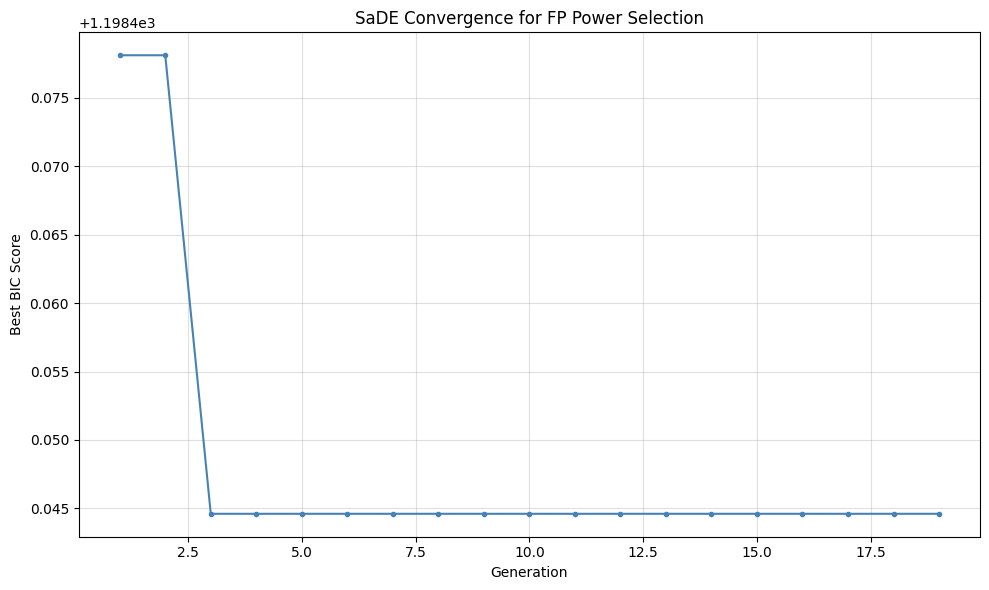


FITTING FINAL MODELS

Metric               | Traditional Cox    | FP Cox (SaDE)       
-----------------------------------------------------------------
Concordance Index    | 0.6413             | 0.6413              
-----------------------------------------------------------------


In [11]:
# ── Dataset 1: Simulated Data ─────────────────────────────────────────────────
sd_df = pd.read_csv('C:/Users/RASHMIKA/Desktop/4th/research/New folder/CSC-461-8.0-Research-Project/data/preprocess-data/preprocess_simulated_data.csv')
np.random.seed(42)
duration_column = 'Time'
event_column    = 'Event'
my_covariates   = ['Age']
optimizer = FPCoxOptimizer(
    df=sd_df,
    covariates=my_covariates,
    duration_col=duration_column,
    event_col=event_column
)
optimizer.optimize(maxiter=20, popsize=40)

Starting SaDE Optimisation for 2 features...
  Population : 160  |  Generations : 20  |  Budget : 3200 evals

--- Optimal Power Selection (SaDE) ---
  PatientAge: Power 1 = None,  Power 2 = None
  LogNodes: Power 1 = None,  Power 2 = 0.5

  Best BIC   : 765.3460
  Generations: 19  |  Evaluations: 3200


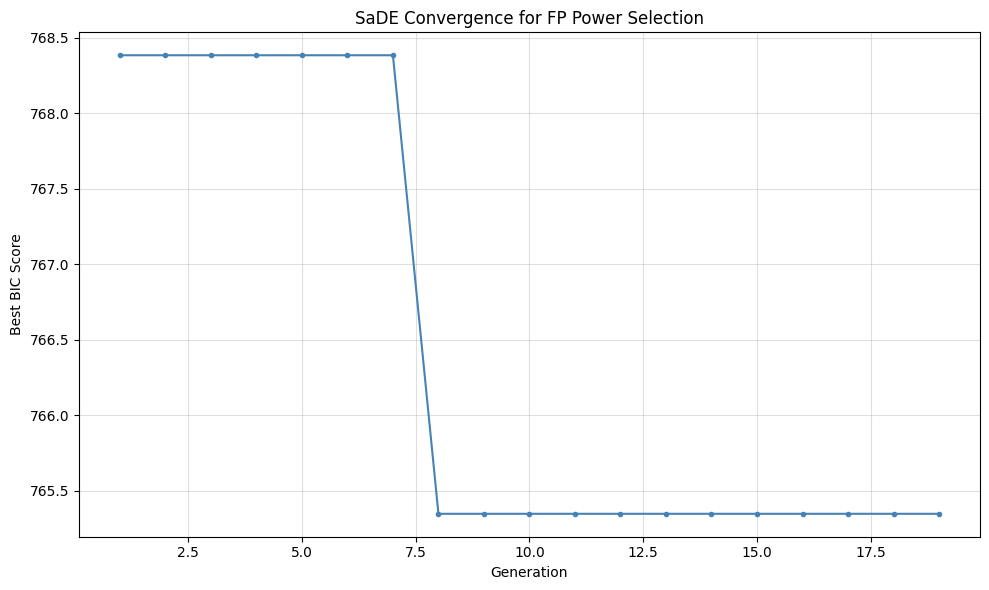


FITTING FINAL MODELS

Metric               | Traditional Cox    | FP Cox (SaDE)       
-----------------------------------------------------------------
Concordance Index    | 0.6682             | 0.6589              
-----------------------------------------------------------------


In [12]:
# ── Dataset 2: Haberman ───────────────────────────────────────────────────────
hm_df = pd.read_csv('C:/Users/RASHMIKA/Desktop/4th/research/New folder/CSC-461-8.0-Research-Project/data/preprocess-data/preprocess_haberman.csv')
np.random.seed(42)
duration_column = 'PatientYearOperation'
event_column    = 'SurvivalStatus'
my_covariates   = ['PatientAge', 'LogNodes']
optimizer = FPCoxOptimizer(
    df=hm_df,
    covariates=my_covariates,
    duration_col=duration_column,
    event_col=event_column
)
optimizer.optimize(maxiter=20, popsize=40)

Starting SaDE Optimisation for 5 features...
  Population : 400  |  Generations : 20  |  Budget : 8000 evals

--- Optimal Power Selection (SaDE) ---
  log_pgr: Power 1 = 2.5,  Power 2 = None
  log_nodes: Power 1 = -3,  Power 2 = 0.5
  age: Power 1 = -0.5,  Power 2 = -2.5
  meno: Power 1 = None,  Power 2 = None
  size: Power 1 = None,  Power 2 = 0

  Best BIC   : 3474.6537
  Generations: 19  |  Evaluations: 8000


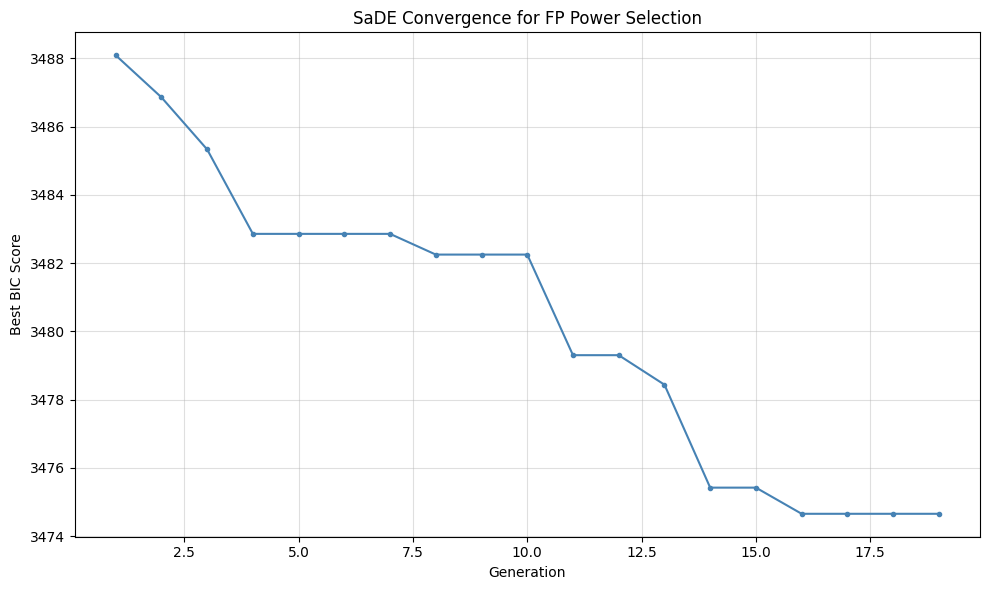


FITTING FINAL MODELS

Metric               | Traditional Cox    | FP Cox (SaDE)       
-----------------------------------------------------------------
Concordance Index    | 0.6895             | 0.7025              
-----------------------------------------------------------------


In [13]:
# ── Dataset 3: GBSG ───────────────────────────────────────────────────────────
gb_df = pd.read_csv('C:/Users/RASHMIKA/Desktop/4th/research/New folder/CSC-461-8.0-Research-Project/data/preprocess-data/preprocess_gbsg.csv')
np.random.seed(42)
duration_column = 'rfstime'
event_column    = 'status'
my_covariates   = ['log_pgr', 'log_nodes', 'age', 'meno', 'size']
optimizer = FPCoxOptimizer(
    df=gb_df,
    covariates=my_covariates,
    duration_col=duration_column,
    event_col=event_column
)
optimizer.optimize(maxiter=20, popsize=40)

## Quick Demo (synthetic data)

A self-contained demo using synthetic data so you can verify the notebook
runs without needing external CSV files.

Starting SaDE Optimisation for 3 features...
  Population : 60  |  Generations : 20  |  Budget : 1200 evals

--- Optimal Power Selection (SaDE) ---
  age: Power 1 = None,  Power 2 = None
  biomarker1: Power 1 = None,  Power 2 = None
  biomarker2: Power 1 = None,  Power 2 = -0.5

  Best BIC   : 1992.8754
  Generations: 19  |  Evaluations: 1200


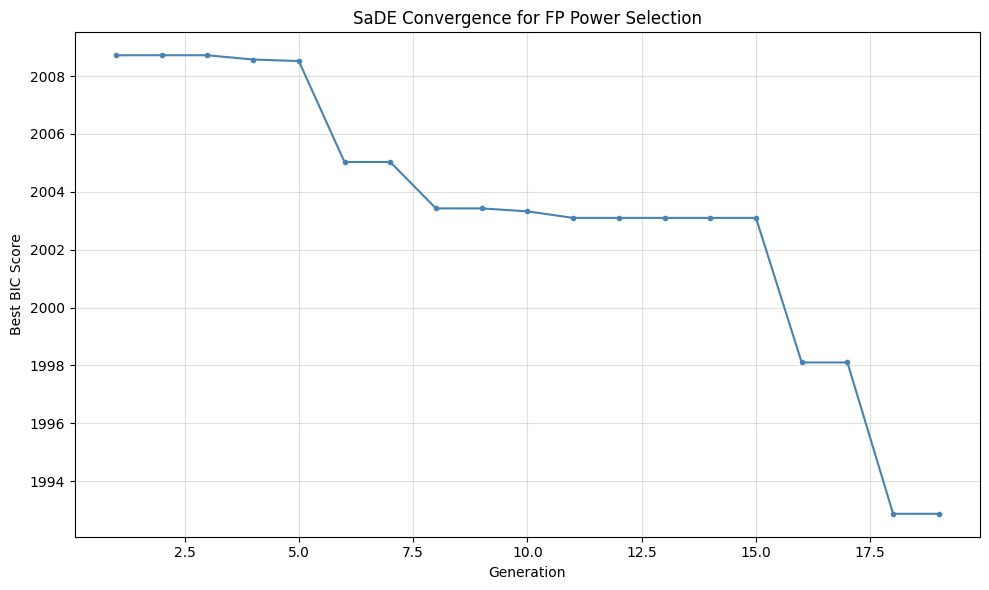


FITTING FINAL MODELS

Metric               | Traditional Cox    | FP Cox (SaDE)       
-----------------------------------------------------------------
Concordance Index    | 0.5210             | 0.5303              
-----------------------------------------------------------------


In [14]:
np.random.seed(42)
n = 300
demo_df = pd.DataFrame({
    'age'       : np.random.uniform(30, 80, n),
    'biomarker1': np.random.exponential(1.5, n),
    'biomarker2': np.random.normal(50, 10, n),
    'duration'  : np.random.randint(1, 100, n),
    'event'     : np.random.binomial(1, 0.7, n),
})

optimizer = FPCoxOptimizer(
    df           = demo_df,
    covariates   = ['age', 'biomarker1', 'biomarker2'],
    duration_col = 'duration',
    event_col    = 'event'
)

optimizer.optimize(maxiter=20, popsize=10)   # quick run; increase for better results